In [76]:
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.dates as mdates

start_day = 6
end_day   = 30
dt = 10
isave = 100 #360 # 6 
start_date = "2024-08-%02d 00:00" % start_day
end_date   = "2024-08-%02d 00:00" % end_day


dates = pd.date_range(start_date, end_date, freq="%ds" % dt)

model = xr.open_dataset("2024_heat_flux.nc")

# model.isel(time=-1).values = model.isel(time=-2).values

nt = len(model.time.values)
times = dates[::isave]
times = times[0:nt]
print(times[-1])

2024-08-27 23:46:40


/tmp/ipykernel_125626/3392547570.py:17: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  model = xr.open_dataset("2024_heat_flux.nc")


 DESCRIPTION:
  This subroutine calculates the short--wave net radiation based on
  solar zenith angle, year day, longitude, latitude, and fractional cloud cover.
  No corrections for albedo - must be done by calls to {\tt albedo\_water()} and
  if ice is included {\tt albedo\_ice()}.
  The basic formula for the short-wave radiation at the surface, $Q_s$,
  has been taken from \cite{RosatiMiyacoda88}, who adapted the work
  of \cite{Reed77} and \cite{SimpsonPaulson99}:

  \begin{equation}
  Q_s=Q_{tot} (1-0.62 C + 0.0019 \beta) (1-\alpha),
  \end{equation}

  with the total radiation reaching the surface under clear skies,
  $Q_{tot}$, the fractional cloud cover, $C$, the solar noon altitude,
  $\beta$, and the albedo, $\alpha$.

In [77]:
# Load interpolated thermistor data
# Temperature 

fn = "/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/august6-28/interpolated_temperature_profile.feather"

thermistor = pd.read_feather(fn)
thermistor = thermistor.iloc[::isave, :]
thermistor = thermistor.iloc[0:nt, :]
thermistor0 = thermistor
thermistor = thermistor.iloc[:, -45:-1]
# print(thermistor.index)
# print(thermistor.index)
# print(thermistor.columns)

<xarray.DataArray 'z' (z: 60)> Size: 240B
array([5.95, 5.85, 5.75, 5.65, 5.55, 5.45, 5.35, 5.25, 5.15, 5.05, 4.95, 4.85,
       4.75, 4.65, 4.55, 4.45, 4.35, 4.25, 4.15, 4.05, 3.95, 3.85, 3.75, 3.65,
       3.55, 3.45, 3.35, 3.25, 3.15, 3.05, 2.95, 2.85, 2.75, 2.65, 2.55, 2.45,
       2.35, 2.25, 2.15, 2.05, 1.95, 1.85, 1.75, 1.65, 1.55, 1.45, 1.35, 1.25,
       1.15, 1.05, 0.95, 0.85, 0.75, 0.65, 0.55, 0.45, 0.35, 0.25, 0.15, 0.05],
      dtype=float32)
Coordinates:
  * z        (z) float32 240B 5.95 5.85 5.75 5.65 5.55 ... 0.35 0.25 0.15 0.05
[28.10525694         nan         nan ...         nan         nan
         nan]


(22.0, 29.0)

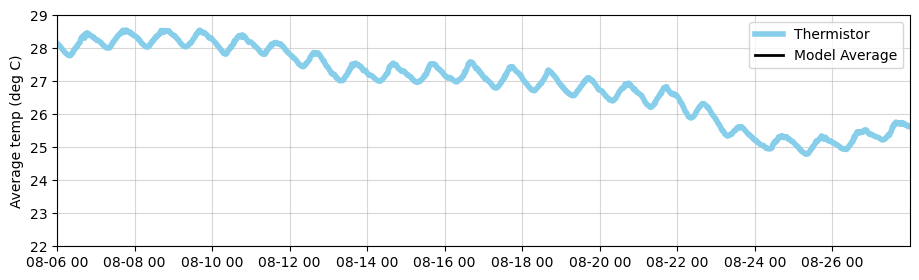

In [85]:
model_av = model.C.sel(z=slice(5,0)).mean(dim='z').values
# model_av = model.C.mean(dim='z').values
model_av[-1] = model_av[-2]  # Fix last value to match thermistor length
print(model.C.z)
# print("model=", model_av.shape)
# print(model_av)
# print("times=", times.shape)
thermistor_av = thermistor.mean(axis=1).values

print(model_av)

fig = plt.figure(figsize=(11, 3))
ax = fig.add_subplot(111)
plt.plot(thermistor.index, thermistor_av, label="Thermistor", color='skyblue', linewidth=4)
plt.plot(times, model_av, label="Model Average", color='black', linewidth=2)
ax.grid(alpha=0.5)
ax.set_ylabel("Average temp (deg C)")
ax.legend() 
ax.xaxis.set_major_locator(mdates.HourLocator(interval=48))
ax.set_xlim(thermistor.index[0], thermistor.index[-1])
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.set_ylim(22, 29)

# print(model_av)


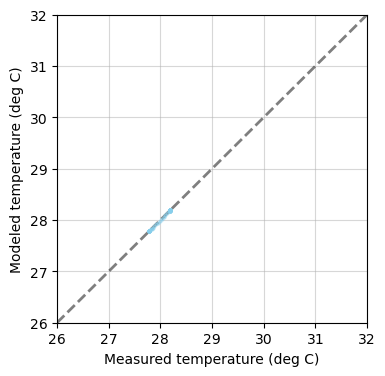

In [79]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)

ax.set_xlim(26, 32)
ax.set_ylim(26, 32)
ax.plot([26, 32], [26, 32], '--',color='black',  linewidth=2, alpha=0.5)

for i in range(0, 100):
    ax.plot(thermistor0.iloc[i,:], model.C.isel(time=i).values, '.', color="skyblue", alpha=0.5, markersize=4)
ax.set_xlabel("Measured temperature (deg C)")
ax.set_ylabel("Modeled temperature (deg C)")
ax.grid(alpha=0.5)


In [80]:
# rmse = [] 
# for i in range(1, nt-10):
#     rmse0 = np.sqrt((thermistor.iloc[i,:] - model.C.isel(time=i).values)**2)  
#     rmse.append(np.mean(rmse0))

# fig = plt.figure(figsize=(7,2)) 
# ax = fig.add_subplot(111)
# ax.plot(thermistor.index[0:-1], rmse[0:-1])
# ax.set_ylabel("RMSE (deg C)")
# ax.grid(alpha=0.5)
# ax.xaxis.set_major_locator(mdates.DayLocator(2))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

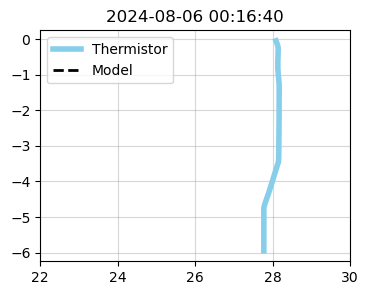

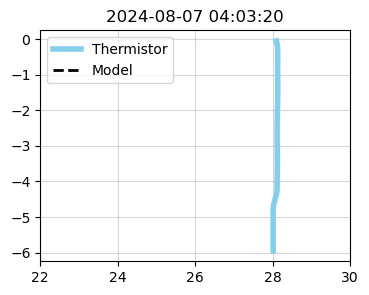

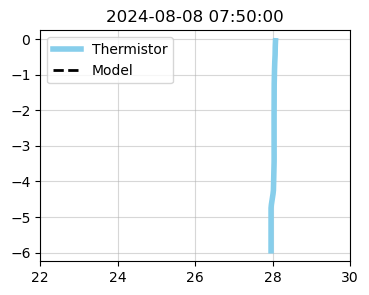

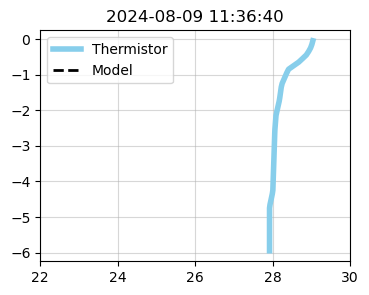

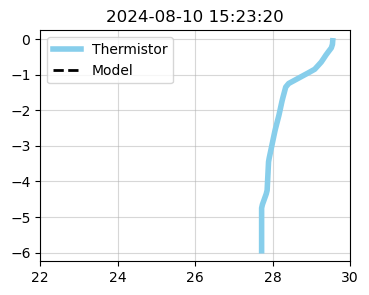

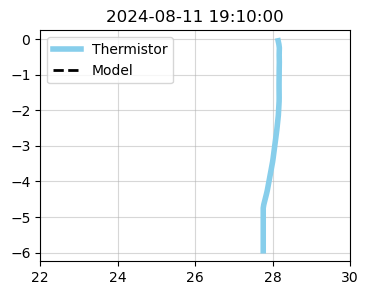

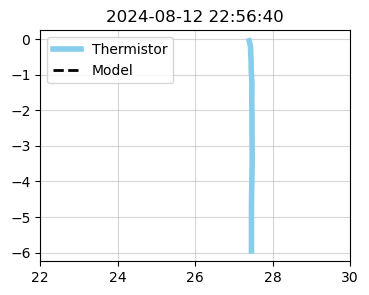

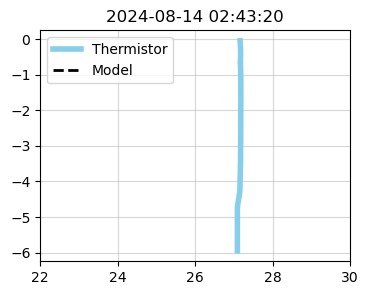

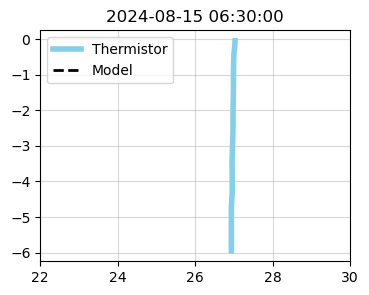

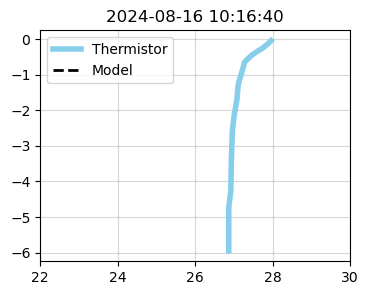

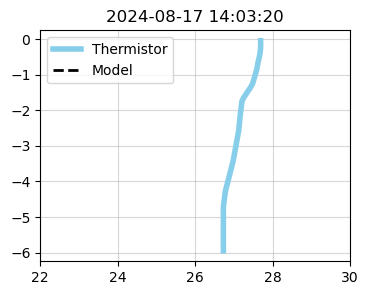

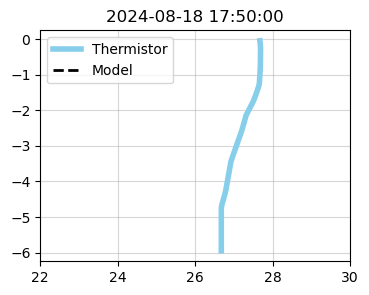

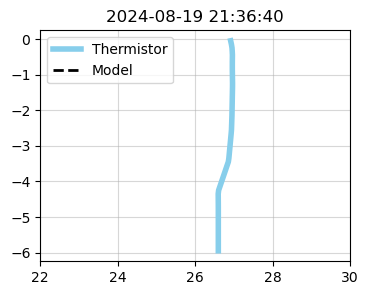

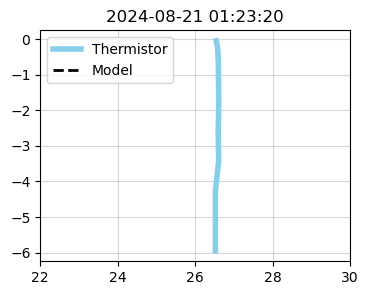

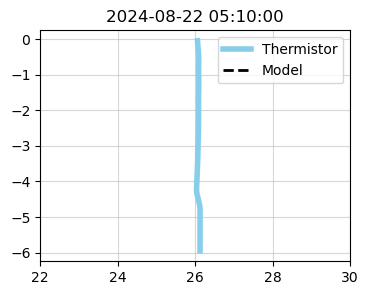

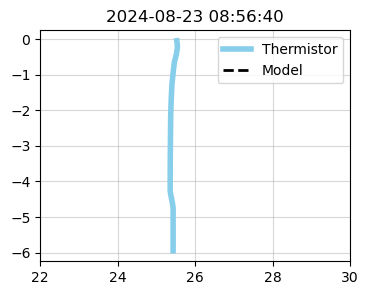

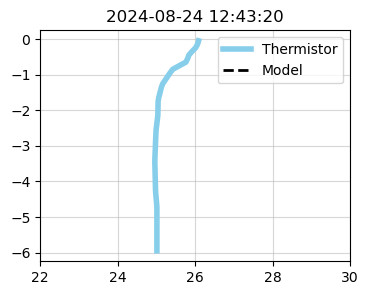

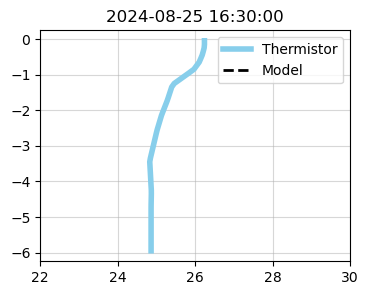

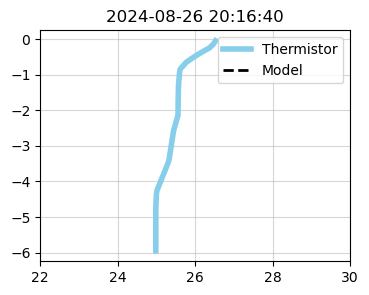

In [81]:
z = model.z.values
import time 
# /max(thermistor.iloc[j, :])
# /max(model.C.isel(time=j).values)
for j in range(1,nt,100): 
    fig = plt.figure(figsize=(4,3)) 
    plt.plot(thermistor0.iloc[j, :], -z, label="Thermistor", color='skyblue', linewidth=4)
    plt.plot(model.C.isel(time=j).values, -z, '--', label="Model", color='black', linewidth=2)

    plt.title("%s" % thermistor.index[j])
    ax = plt.gca()
    ax.grid(alpha=0.5)
    ax.set_xlim(22, 30)
    ax.legend()
    plt.show()



In [82]:
string = ' ' 
for val in thermistor.iloc[0,:].values:
    string += ' %f,' % val
print(string)

  27.834993, 27.853380, 27.878350, 27.915170, 27.951990, 27.988810, 28.025630, 28.062450, 28.099270, 28.136090, 28.172910, 28.181460, 28.182300, 28.183140, 28.183980, 28.184820, 28.185660, 28.186500, 28.187340, 28.188050, 28.188283, 28.188517, 28.188750, 28.188983, 28.189087, 28.189180, 28.189273, 28.189367, 28.189280, 28.189093, 28.188907, 28.188720, 28.188400, 28.187840, 28.187280, 28.186720, 28.186233, 28.186700, 28.187167, 28.187027, 28.186840, 28.188853, 28.191467, 28.189520,


11.915697
2.75


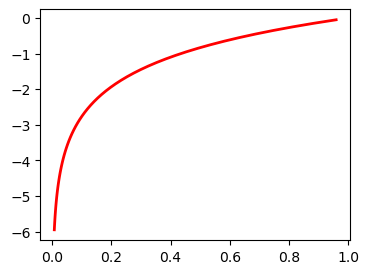

In [83]:
n1 = 1.2


adjustment = np.sum(np.exp(-z/n1)) 

print(adjustment)
# print(adjustment)400 * (10 * 1/adjustment * 
curve = (np.exp(-z/n1)) 

fig = plt.figure(figsize=(4,3))
plt.plot(curve, -z, label="n1 = %.2f" % n1, color='red', linewidth=2)

ind = sum(curve<0.1) 
print(z[ind])


In [84]:

# temp = pd.read_csv(fn, header=1)
# temp = temp.loc[temp['STAT'] == "Average"]
# temp["time"] = pd.to_datetime(temp["TIMESTAMP"])

# # PLZ
# temp_wp = temp[temp['SITE'] == 'WEB']
# temp_wp = temp_wp.groupby('time').mean()


# temp_up = temp[temp['SITE'] == 'PLZ']
# temp_up = temp_up.groupby('time').mean()

# temp_tb = temp[temp['SITE'] == 'TB']
# temp_tb = temp_tb.groupby('time').mean()
# Open feather file 